In [187]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [188]:
df_file = Path("/exp/sbnd/app/users/bharris/TriggerEff/cafpyana/trigger_eff_zerobias_fnicolas_10.df")
store = pd.HDFStore(df_file, mode="r")
keys = store.keys()
print("Available keys:", keys)

def pick_key(keys, prefix):
    matches = [k for k in keys if k.strip("/").startswith(prefix)]
    if not matches:
        raise KeyError(f"No key starting with '{prefix}' in {keys}")
    return sorted(matches)[0]

Available keys: ['/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/pot_0', '/rec_0', '/split', '/trigger_0']


In [189]:
rec = store[pick_key(keys, "rec")]
print(f"rec shape: {rec.shape}")
rec.head()

rec shape: (252707, 97)


slc  \
                                                                  is_clear_cosmic   
                                                                                    
                                                                                    
                                                                                    
                                                                                    
__ntuple entry rec.slc..index (rec.slc.reco.pfp..index, , , , , )                   
0        0     0              0                                                 0   
                              1                                                 0   
                              2                                                 0   
               1              0                                                 1   
                              1                                                 1   

                                                                              \
                                                                      vertex   
                                                                           x   
                                                                               
                                                                               
                                                                               
__ntuple entry rec.slc..index (rec.slc.reco.pfp..index, , , , , )              
0        0     0              0                                    98.906860   
                              1                                    98.906860   
                              2                                    98.906860   
               1              0                                   -74.308151   
                              1                                   -74.308151   

                                                                               \
                                                                                
                                                                            y   
                                                                                
                                                                                
                                                                                
__ntuple entry rec.slc..index (rec.slc.reco.pfp..index, , , , , )               
0        0     0              0                                    -88.434868   
                              1                                    -88.434868   
                              2                                    -88.434868   
               1              0                                    201.592957   
                              1                                    201.592957   

                                                                               \
                                                                                
                                                                            z   
                                                                                
                                                                                
                                                                                
__ntuple entry rec.slc..index (rec.slc.reco.pfp..index, , , , , )               
0        0     0              0                                      0.967746   
                              1                                      0.967746   
                              2                                      0.967746   
               1              0                                    411.407684   
                              1                                    411.407684   

                                                                        \
                                                                  self   
  

In [190]:
trigger = store[pick_key(keys, "trigger")]
print(f"trigger shape: {trigger.shape}")
print("columns:", list(trigger.columns))
print("index:", trigger.index.names)
print("HLT rows:", int((trigger.index.get_level_values("ptb_is_hlt") == True).sum()))
print("LLT rows:", int((trigger.index.get_level_values("ptb_is_hlt") == False).sum()))
trigger.head()

trigger shape: (2239687, 13)
columns: ['ptb_timestamp', 'ptb_bit', 'trigger_id', 'gate_id', 'trigger_count', 'gate_count', 'gate_delta', 'global_trigger_time', 'prev_global_trigger_time', 'global_trigger_det_time', 'trigger_within_gate', 'beam_gate_det_time', 'beam_gate_time_abs']
index: ['__ntuple', 'entry', 'ptb_is_hlt', 'ptb_idx']
HLT rows: 125390
LLT rows: 2114297


ptb_timestamp  ptb_bit  trigger_id  \
__ntuple entry ptb_is_hlt ptb_idx                                             
0        0     False      0        1739680786662587300       14           0   
                          1        1739680786662587300       18           0   
                          2        1739680786662587300       20           0   
                          3        1739680786662587300       21           0   
                          4        1739680786662614360        7           0   

                                   gate_id  trigger_count  gate_count  \
__ntuple entry ptb_is_hlt ptb_idx                                       
0        0     False      0              0              0           0   
                          1              0              0           0   
                          2              0              0           0   
                          3              0              0           0   
                          4              0              0           0   

                                   gate_delta  global_trigger_time  \
__ntuple entry ptb_is_hlt ptb_idx                                    
0        0     False      0                -1  1739680786664258040   
                          1                -1  1739680786664258040   
                          2                -1  1739680786664258040   
                          3                -1  1739680786664258040   
                          4                -1  1739680786664258040   

                                   prev_global_trigger_time  \
__ntuple entry ptb_is_hlt ptb_idx                             
0        0     False      0                               0   
                          1                               0   
                          2                               0   
                          3                               0   
                          4                               0   

                                   global_trigger_det_time  \
__ntuple entry ptb_is_hlt ptb_idx                            
0        0     False      0                            NaN   
                          1                            NaN   
                          2                            NaN   
                          3                            NaN   
                          4                            NaN   

                                   trigger_within_gate  beam_gate_det_time  \
__ntuple entry ptb_is_hlt ptb_idx                                            
0        0     False      0                        NaN                 NaN   
                          1                        NaN                 NaN   
                          2                        NaN                 NaN   
                          3                        NaN                 NaN   
                          4                        NaN                 NaN   

                                    beam_gate_time_abs  
__ntuple entry ptb_is_hlt ptb_idx                       
0        0     False      0        1739680786664258040  
                          1        1739680786664258040  
                          2        1739680786664258040  
                          3        1739680786664258040  
                          4        1739680786664258040

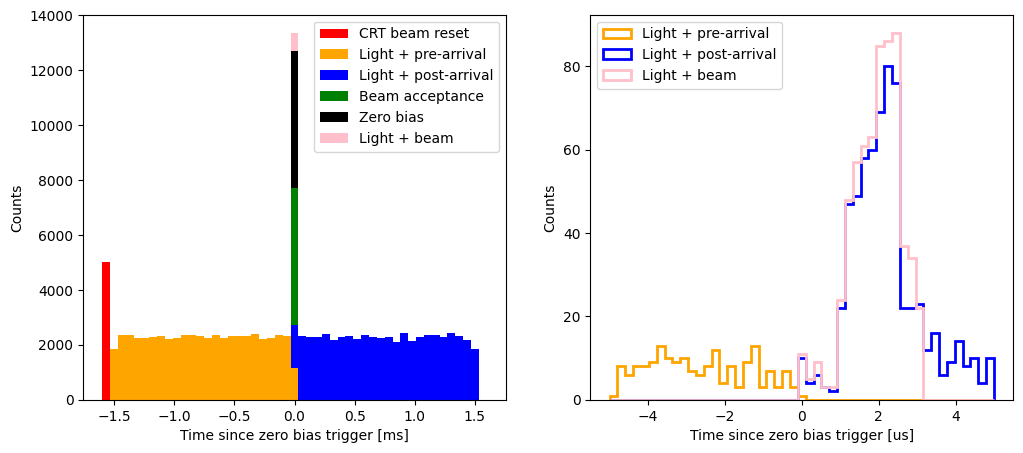

In [191]:
# get all hlt rows
hlt = trigger.xs(True, level="ptb_is_hlt").copy()

zb_ts = (
    hlt[hlt.ptb_bit == 1]["ptb_timestamp"] # keep only rows with ptb_bit == 1 and select the timestamp column
    .groupby(level=["__ntuple", "entry"]) # split series into groups by ntuple and entry
    .first() # get the first timestamp in each group
    .rename("zb_ts") # rename the timestamp column to zb_ts
)

# broadcast the zero bias timestamp to all rows with the same ntuple and entry
hlt = hlt.join(zb_ts, on=["__ntuple", "entry"])

# for all rows, calculate the time from the zero bias timestamp to the ptb_timestamp
hlt["dt_ms"] = (hlt["ptb_timestamp"].astype("int64") - hlt["zb_ts"].astype("int64")) / 1e6
hlt["dt_us"] = (hlt["ptb_timestamp"].astype("int64") - hlt["zb_ts"].astype("int64")) / 1e3

hlt_defs = [
    (20, "CRT beam reset", "red"),
    (28, "Light + pre-arrival", "orange"),
    (29, "Light + post-arrival", "blue"),
    (26, "Beam acceptance", "green"),
    (1, "Zero bias", "black"),
    (2, "Light + beam", "pink")
]

hlt_data = [hlt[hlt.ptb_bit == bit]["dt_ms"] for bit, _, _ in hlt_defs]
hlt_labels = [label for _, label, _ in hlt_defs]
hlt_colors = [color for _, _, color in hlt_defs]

fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].hist(hlt_data, bins=np.linspace(-1.6, 1.6, 50), label=hlt_labels, color=hlt_colors, stacked=True)
ax[0].legend()
ax[0].set_xlabel("Time since zero bias trigger [ms]")
ax[0].set_ylabel("Counts")

subset_hlt_defs = [hlt_defs[i] for i in [1,2,5]]
subset_hlt_data = [hlt[hlt.ptb_bit == bit]["dt_ms"] for bit, _, _ in subset_hlt_defs]
subset_hlt_labels = [label for _, label, _ in subset_hlt_defs]
subset_hlt_colors = [color for _, _, color in subset_hlt_defs]

for bit, label, color in subset_hlt_defs:
    ax[1].hist(hlt.query("ptb_bit == @bit")["dt_us"], bins=np.linspace(-5, 5, 50), label=label, color=color, histtype="step", lw=2)

ax[1].legend()
ax[1].set_xlabel("Time since zero bias trigger [us]")
ax[1].set_ylabel("Counts")

plt.show()

# light + beam is made with mtca med
# light + post arrival made with mtca high

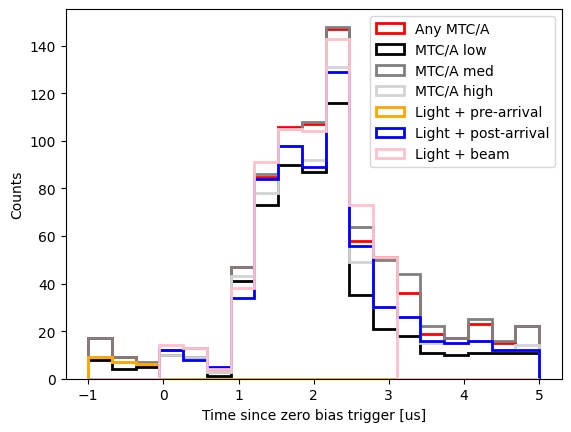

In [192]:
llt = trigger.xs(False, level="ptb_is_hlt").copy()
llt = llt.join(zb_ts, on=["__ntuple", "entry"])
llt["dt_ms"] = (llt["ptb_timestamp"].astype("int64") - llt["zb_ts"].astype("int64")) / 1e6
llt["dt_us"] = (llt["ptb_timestamp"].astype("int64") - llt["zb_ts"].astype("int64")) / 1e3

llt_defs = [
    (14, "Any MTC/A", "red"),
    # (15, "CAEN 10", "red"),
    # (16, "???", "salmon"),
    # (17, "Any CAEN", "green"),
    (18, "MTC/A low", "black"),
    (21, "MTC/A med", "grey"),
    (20, "MTC/A high", "lightgrey"),
]

bins  = np.linspace(-1, 5, 20)
lw = 2

for bit, label, color in llt_defs:
    plt.hist(llt[llt.ptb_bit == bit]["dt_us"], bins=bins, label=label, color=color, histtype="step", lw=lw)
for bit,label,color in subset_hlt_defs:
    plt.hist(hlt[hlt.ptb_bit == bit]["dt_us"], bins=bins, label=label, color=color, histtype="step", lw=lw)  

plt.legend()
plt.xlabel("Time since zero bias trigger [us]")
plt.ylabel("Counts")
plt.show()

# this doesn't make sense

In [193]:
zero_bias = hlt[hlt.ptb_bit == 1]
light_beam = hlt[hlt.ptb_bit == 2]

print(f"{len(light_beam)}/{len(zero_bias)} ({len(light_beam) / len(zero_bias):.2%}) of zero bias triggers have light + beam")




636/5000 (12.72%) of zero bias triggers have light + beam


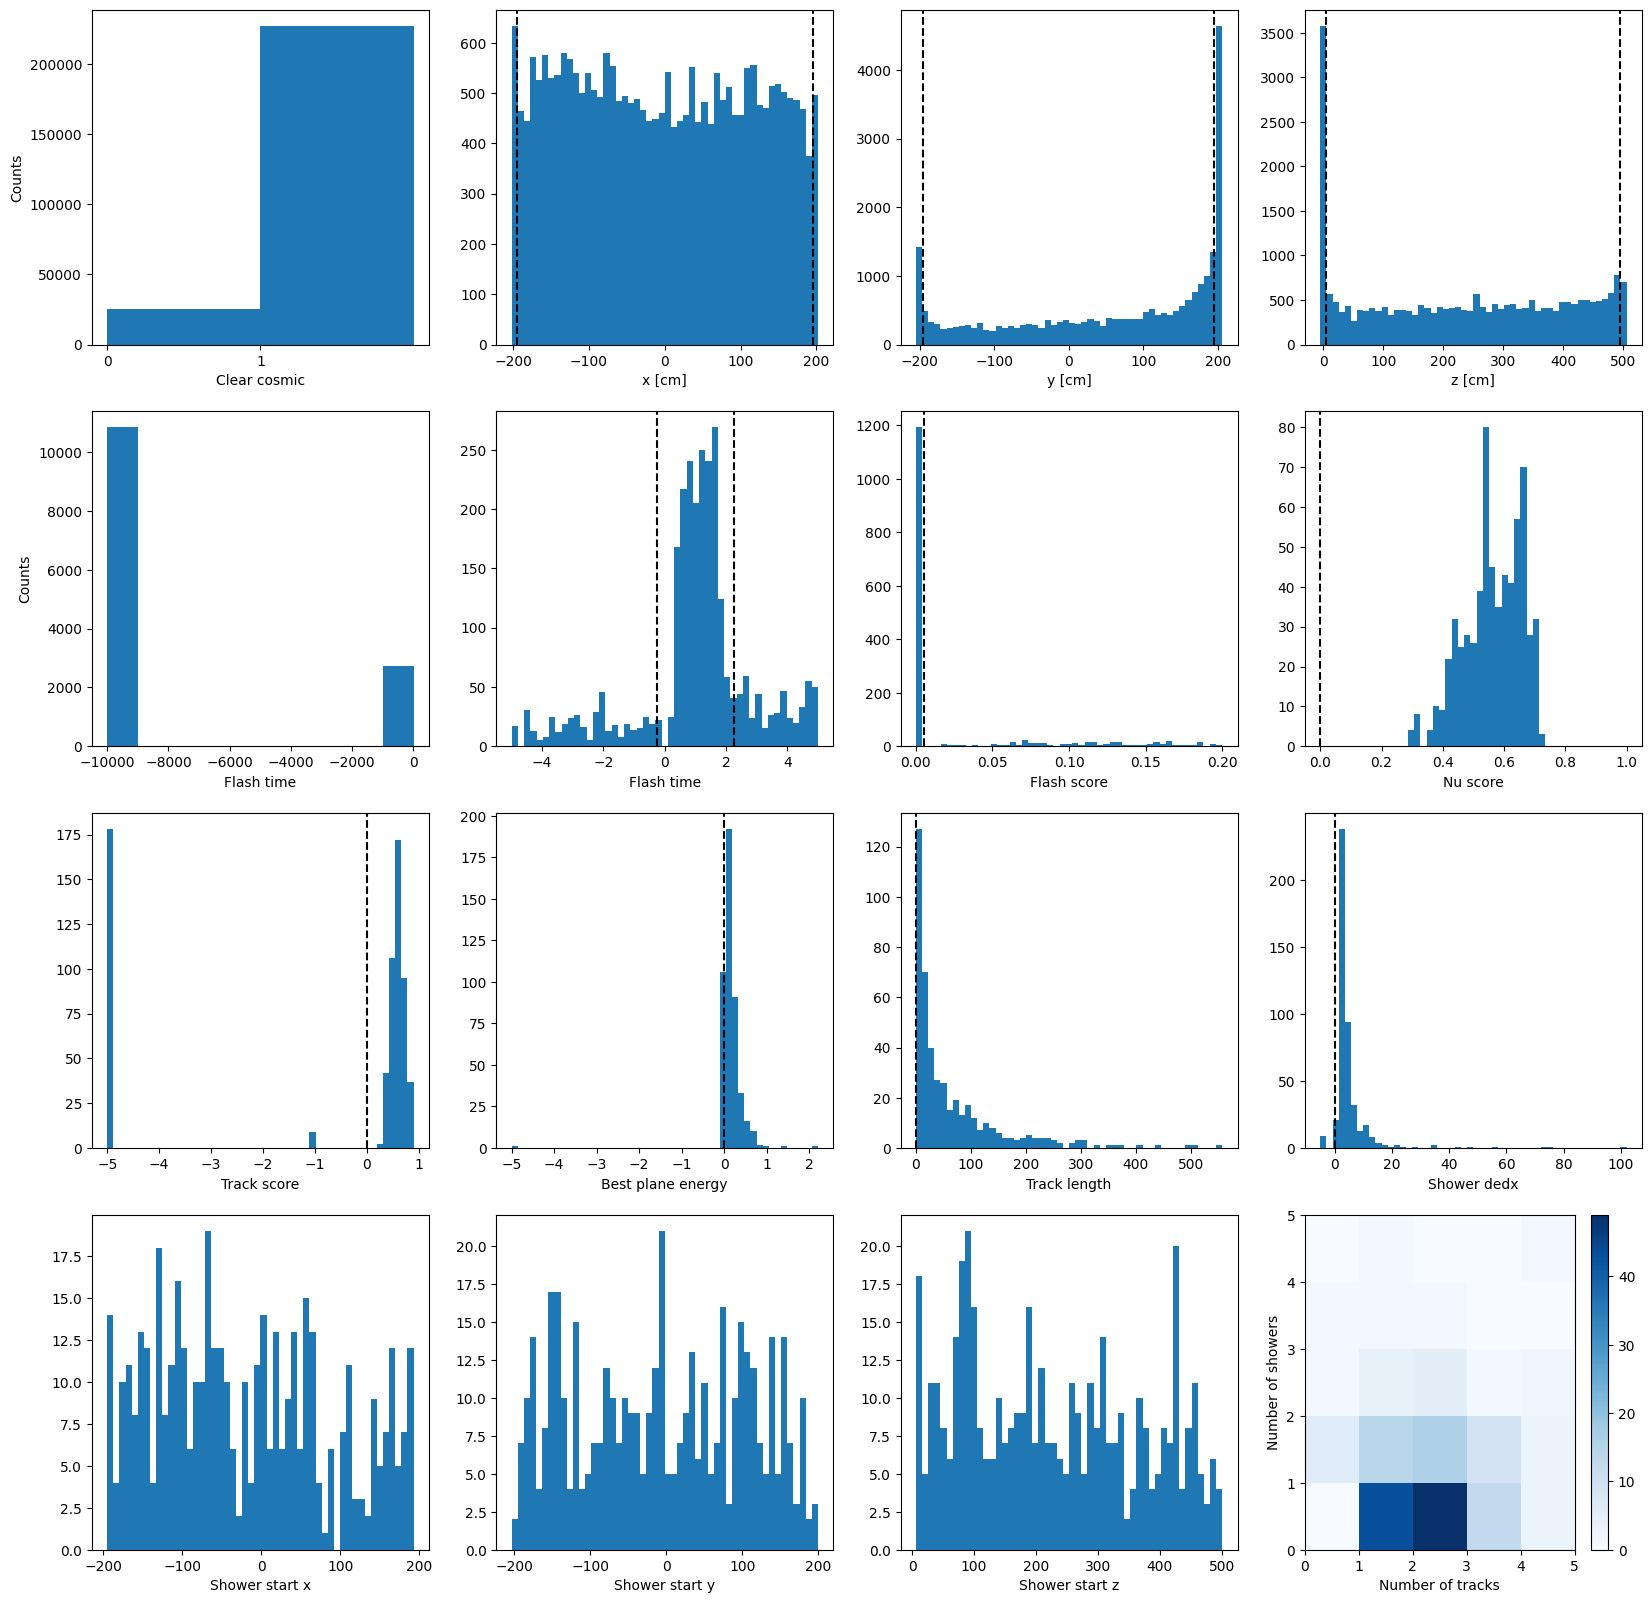

/tmp/ipykernel_858790/1111227414.py:120: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  topo_mask = pass_topo_mask.reindex(rec.index.droplevel(-1)).fillna(False) # broadcast to ntuple,entry,slc,pfp


In [368]:
fig,ax = plt.subplots(4,4,figsize=(20,20)) 

is_clear_cosmic = rec.slc.is_clear_cosmic
ax[0,0].hist(is_clear_cosmic,bins=(0,1,2));
ax[0,0].set_xticks([0,1]);
ax[0,0].set_xlabel("Clear cosmic");
ax[0,0].set_ylabel("Counts");
cosmic_mask = rec.slc.is_clear_cosmic==0

fv_x = 195
fv_y = 195
fv_z_min = 5
fv_z_max = 495
nbins = 50
vertex_x = rec.slc.vertex.x[cosmic_mask]
ax[0,1].hist(vertex_x,bins=nbins);
ax[0,1].axvline(fv_x,color="k",ls="--");
ax[0,1].axvline(-fv_x,color="k",ls="--");
ax[0,1].set_xlabel("x [cm]");
vertex_y = rec.slc.vertex.y[cosmic_mask]
ax[0,2].hist(vertex_y,bins=nbins);
ax[0,2].axvline(fv_y,color="k",ls="--");
ax[0,2].axvline(-fv_y,color="k",ls="--");
ax[0,2].set_xlabel("y [cm]");
vertex_z = rec.slc.vertex.z[cosmic_mask]
ax[0,3].hist(vertex_z,bins=nbins);
ax[0,3].axvline(fv_z_min,color="k",ls="--");
ax[0,3].axvline(fv_z_max,color="k",ls="--");
ax[0,3].set_xlabel("z [cm]");
fv_x_mask = (rec.slc.vertex.x < fv_x) & (rec.slc.vertex.x > -fv_x)
fv_y_mask = (rec.slc.vertex.y < fv_y) & (rec.slc.vertex.y > -fv_y)
fv_z_mask = (rec.slc.vertex.z < fv_z_max) & (rec.slc.vertex.z > fv_z_min)

flash_time = rec.slc.barycenterFM.flashTime[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask]
ax[1,0].hist(flash_time)
ax[1,0].set_xlabel("Flash time");
ax[1,0].set_ylabel("Counts");

ft_min = -0.25
ft_max = 2.25
ax[1,1].hist(flash_time,bins=np.linspace(-5,5,nbins));
ax[1,1].axvline(ft_min,color="k",ls="--");
ax[1,1].axvline(ft_max,color="k",ls="--");
ax[1,1].set_xlabel("Flash time");
flash_time_mask = (rec.slc.barycenterFM.flashTime > ft_min) & (rec.slc.barycenterFM.flashTime < ft_max)

fs_min = 0.005
flash_score = rec.slc.barycenterFM.score[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask]
ax[1,2].hist(flash_score,bins=np.linspace(0,0.2,nbins));
ax[1,2].axvline(fs_min,color="k",ls="--");
ax[1,2].set_xlabel("Flash score");
flash_score_mask = rec.slc.barycenterFM.score > fs_min

nu_score_min = 0
nu_score = rec.slc.nu_score[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask]
ax[1,3].hist(nu_score,bins=np.linspace(0,1,nbins))
ax[1,3].axvline(nu_score_min,color="k",ls="--");
ax[1,3].set_xlabel("Nu score");
nu_score_mask = rec.slc.nu_score > nu_score_min

track_score_min = 0
track_score = rec.pfp.trackScore[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask]
ax[2,0].hist(track_score,bins=nbins)
ax[2,0].axvline(track_score_min,color="k",ls="--");
ax[2,0].set_xlabel("Track score");
track_score_mask = rec.pfp.trackScore > track_score_min

bestplane_energy_min = 0
bestplane_energy = rec.pfp.shw.bestplane_energy[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask & track_score_mask]
ax[2,1].hist(bestplane_energy,bins=nbins)
ax[2,1].axvline(bestplane_energy_min,color="k",ls="--");
ax[2,1].set_xlabel("Best plane energy");
bestplane_energy_mask = rec.pfp.shw.bestplane_energy > bestplane_energy_min

track_length_min = 0
track_length = rec.pfp.trk.len[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask & track_score_mask & bestplane_energy_mask]
ax[2,2].hist(track_length,bins=nbins)
ax[2,2].axvline(track_length_min,color="k",ls="--");
ax[2,2].set_xlabel("Track length");
track_length_mask = rec.pfp.trk.len > track_length_min

shower_dedx_min = 0
shower_dedx = rec.pfp.shw.bestplane_dEdx[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask & track_score_mask & bestplane_energy_mask & track_length_mask]
ax[2,3].hist(shower_dedx,bins=nbins)
ax[2,3].axvline(shower_dedx_min,color="k",ls="--");
ax[2,3].set_xlabel("Shower dedx");
shower_dedx_mask = rec.pfp.shw.bestplane_dEdx > shower_dedx_min

shower_start_x = rec.pfp.shw.start.x[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask & track_score_mask & bestplane_energy_mask & track_length_mask & shower_dedx_mask]
ax[3,0].hist(shower_start_x,bins=nbins)
ax[3,0].set_xlabel("Shower start x");
shower_start_x_mask = rec.pfp.shw.start.x != -999

shower_start_y = rec.pfp.shw.start.y[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask & track_score_mask & bestplane_energy_mask & track_length_mask & shower_dedx_mask & shower_start_x_mask]
ax[3,1].hist(shower_start_y,bins=nbins)
ax[3,1].set_xlabel("Shower start y");
shower_start_y_mask = rec.pfp.shw.start.y != -999

shower_start_z = rec.pfp.shw.start.z[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask & track_score_mask & bestplane_energy_mask & track_length_mask & shower_dedx_mask & shower_start_x_mask & shower_start_y_mask]
ax[3,2].hist(shower_start_z,bins=nbins)
ax[3,2].set_xlabel("Shower start z");
shower_start_z_mask = rec.pfp.shw.start.z != -999

sel = rec[cosmic_mask & fv_x_mask & fv_y_mask & fv_z_mask & flash_time_mask & flash_score_mask & nu_score_mask & track_score_mask & bestplane_energy_mask & track_length_mask & shower_dedx_mask & shower_start_x_mask & shower_start_y_mask & shower_start_z_mask]
is_shw = sel.pfp.trackScore<0.51
is_trk = sel.pfp.trackScore>=.51
levels = ['__ntuple','entry','rec.slc..index']
pfp_in_slc_counts = pd.DataFrame({
    'n_pfp': sel.groupby(level=levels).size(),
    'n_shw': is_shw.groupby(level=levels).sum(),
    'n_trk': is_trk.groupby(level=levels).sum(),
})
plt.hist2d(pfp_in_slc_counts.n_trk,pfp_in_slc_counts.n_shw,bins=np.arange(0,6,1),cmap='Blues')
plt.colorbar()
plt.xlabel("Number of tracks")
plt.ylabel("Number of showers")
plt.show()

pass_topo_mask = (pfp_in_slc_counts.n_shw > 0) #| (pfp_in_slc_counts.n_trk > 0) # did that ntuple,entry,slc combo pass
topo_mask = pass_topo_mask.reindex(rec.index.droplevel(-1)).fillna(False) # broadcast to ntuple,entry,slc,pfp
topo_mask.index = rec.index # relable to add pfp index

In [369]:
mask_list = [
    ("cosmic", cosmic_mask),
    ("fv_x", fv_x_mask),
    ("fv_y", fv_y_mask),
    ("fv_z", fv_z_mask),
    ("flash_time", flash_time_mask),
    ("flash_score", flash_score_mask),
    ("nu_score", nu_score_mask),
    ("track_score", track_score_mask),
    ("bestplane_energy", bestplane_energy_mask),
    ("track_length", track_length_mask),
    ("shower_dedx", shower_dedx_mask),
    ("shower_start_x", shower_start_x_mask),
    ("shower_start_y", shower_start_y_mask),
    ("shower_start_z", shower_start_z_mask),
    ("topo_mask", topo_mask),
]

print(topo_mask.dtype, cosmic_mask.dtype)
print(topo_mask.index.equals(rec.index))

n_pfp = len(rec.pfp.shw.len)
n_slc = rec.groupby(level=["__ntuple","entry","rec.slc..index"]).ngroups
n_ev = rec.groupby(level=["__ntuple","entry"]).ngroups
print(f"                      pfp: {n_pfp} slc: {n_slc} ev: {n_ev}")
mask = pd.Series(True,index=rec.index) 
for name, m in mask_list:
    mask = mask & m
    n_pfp = mask.sum()
    n_slc = rec[mask].groupby(level=["__ntuple","entry","rec.slc..index"]).ngroups
    n_ev = rec[mask].groupby(level=["__ntuple","entry"]).ngroups
    print(f"{name:>20}: pfp: {n_pfp:>6} slc: {n_slc:>5} ev: {n_ev:>4}")


bool bool
True
                      pfp: 252707 slc: 42672 ev: 4999
              cosmic: pfp:  25048 slc:  8823 ev: 4406
                fv_x: pfp:  24034 slc:  8443 ev: 4326
                fv_y: pfp:  17434 slc:  5869 ev: 3606
                fv_z: pfp:  13580 slc:  4417 ev: 3033
          flash_time: pfp:   1833 slc:   569 ev:  381
         flash_score: pfp:    641 slc:   178 ev:  174
            nu_score: pfp:    641 slc:   178 ev:  174
         track_score: pfp:    454 slc:   178 ev:  174
    bestplane_energy: pfp:    453 slc:   178 ev:  174
        track_length: pfp:    451 slc:   178 ev:  174
         shower_dedx: pfp:    442 slc:   178 ev:  174
      shower_start_x: pfp:    442 slc:   178 ev:  174
      shower_start_y: pfp:    442 slc:   178 ev:  174
      shower_start_z: pfp:    442 slc:   178 ev:  174
           topo_mask: pfp:    250 slc:    70 ev:   70


In [370]:
trigger_ne = trigger.groupby(level=["__ntuple","entry"]).size().index
rec_ne = rec.groupby(level=["__ntuple","entry"]).size().index

for t, r in zip(trigger_ne, rec_ne):
    if t != r:
        print(t, r)
        break


(8, 389) (8, 390)


In [371]:
for val in rec:
    print(val)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'nu_score', '', '', '', '')
('slc', 'opt0', 'score', '', '', '')
('slc', 'opt0', 'time', '', '', '')
('slc', 'opt0', 'measPE', '', '', '')
('slc', 'opt0', 'hypoPE', '', '', '')
('slc', 'barycenterFM', 'chargeTotal', '', '', '')
('slc', 'barycenterFM', 'flashTime', '', '', '')
('slc', 'barycenterFM', 'flashPEs', '', '', '')
('slc', 'barycenterFM', 'chi2', '', '', '')
('slc', 'barycenterFM', 'score', '', '', '')
('slc', 'barycenterFM', 'deltaZ', '', '', '')
('slc', 'correctedOpFlash', 'OpFlashT0', '', '', '')
('slc', 'correctedOpFlash', 'NuToFLight', '', '', '')
('slc', 'correctedOpFlash', 'NuToFCharge', '', '', '')
('slc', 'correctedOpFlash', 'OpFlashT0Corrected', '', '', '')
('pfp', 'trk', 'producer', '', '', '')
('pfp', 

70
70


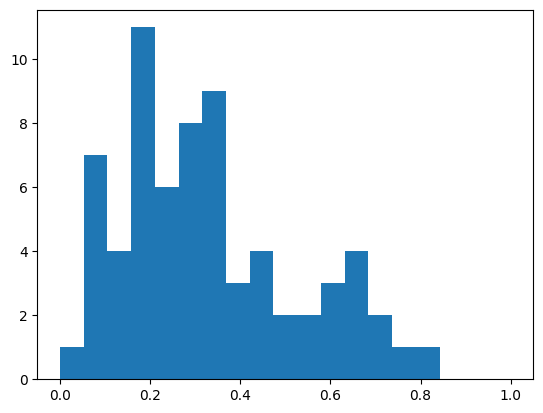

In [379]:
energy = rec[mask].pfp.shw.bestplane_energy
highest_energy_shw_idx = energy.groupby(level=["__ntuple","entry","rec.slc..index"]).idxmax() # get index of highest energy shower in each ntuple,entry,slc
highest_energy_shw_mask = pd.Series(rec.index.isin(highest_energy_shw_idx), index=rec.index)

plt.hist(energy[highest_energy_shw_mask],bins=np.linspace(0,1,20));

print(len(energy[highest_energy_shw_mask]))
final_mask = mask & highest_energy_shw_mask
print(len(energy[final_mask]))

In [373]:
# unique ntuple,entry pairs for final events
ev_keys = rec[final_mask].groupby(level=["__ntuple","entry"]).size().index
print(ev_keys[0])

hlt_sel = hlt.loc[hlt.index.droplevel("ptb_idx").isin(ev_keys)]

zero_bias = hlt_sel[hlt_sel.ptb_bit == 1]
light_beam = hlt_sel[hlt_sel.ptb_bit == 2]
n_light_beam = light_beam.groupby(level=["__ntuple","entry"]).size().reindex(ev_keys,fill_value=0)

print(f"{len(light_beam)}/{len(zero_bias)} ({len(light_beam) / len(zero_bias):.2%}) of zero bias triggers have light + beam")


(0, 53)
125/70 (178.57%) of zero bias triggers have light + beam


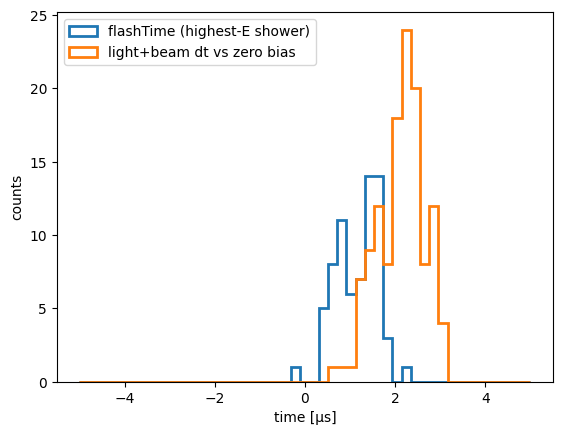

In [ ]:
# flash time of the final highest-energy shower only (one row per selected shower/slice)
flash_final = rec[final_mask].slc.barycenterFM.flashTime

# events those showers belong to
ev_keys = flash_final.index.droplevel(list(range(2, flash_final.index.nlevels))).unique()

# all light+beam HLT times vs zero bias for those events
lb = hlt[(hlt.ptb_bit == 2) & hlt.index.droplevel("ptb_idx").isin(ev_keys)]

bins = np.linspace(-5, 5, 50)

plt.hist(flash_final, bins=bins, histtype="step", lw=2,
         label="flashTime (highest-E shower)")
plt.hist(lb["dt_us"], bins=bins, histtype="step", lw=2,
         label="light+beam dt vs zero bias")
plt.xlabel("time [µs]")
plt.ylabel("counts")
plt.legend()

Text(0, 0.5, '# Light + Beam triggers')

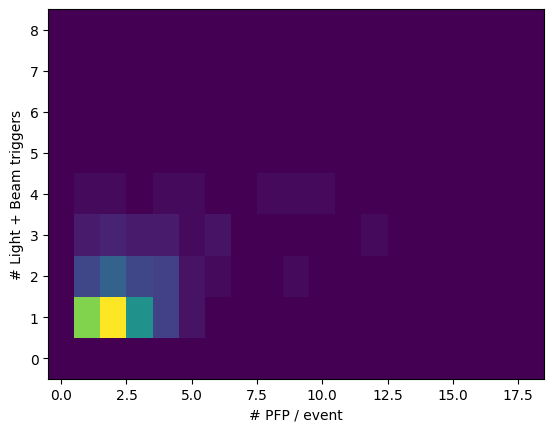

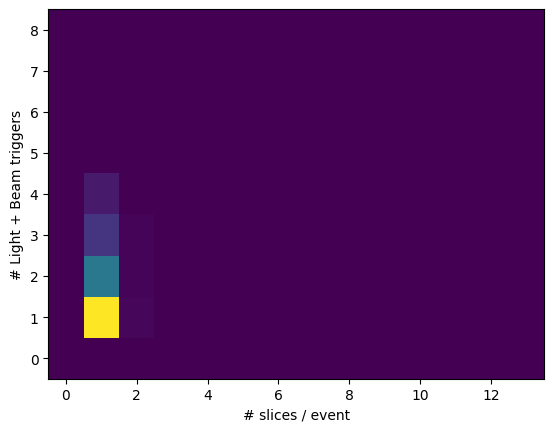

In [363]:


levels_ev = ["__ntuple", "entry"]
levels_slc = ["__ntuple", "entry", "rec.slc..index"]

# population you care about (e.g. after your analysis cuts, before or after max-energy)
df = rec[mask]   # or rec[final_mask], depending on what you want to count

n_pfp_per_ev = df.groupby(level=levels_ev).size()
n_slc_per_ev = df.groupby(level=levels_slc).size().groupby(level=levels_ev).size()
# ^ count unique slices per event: groupby slice then count groups per event

# align trigger counts (0 if none)
n_lb = n_light_beam.reindex(n_pfp_per_ev.index).fillna(0)

# PFP vs light+beam
plt.figure()
plt.hist2d(n_pfp_per_ev, n_lb, bins=(np.arange(0, 20) - 0.5, np.arange(0, 10) - 0.5))
plt.xlabel("# PFP / event")
plt.ylabel("# Light + Beam triggers")

# slices vs light+beam
plt.figure()
n_lb2 = n_light_beam.reindex(n_slc_per_ev.index).fillna(0)
plt.hist2d(n_slc_per_ev, n_lb2, bins=(np.arange(0, 15) - 0.5, np.arange(0, 10) - 0.5))
plt.xlabel("# slices / event")
plt.ylabel("# Light + Beam triggers")